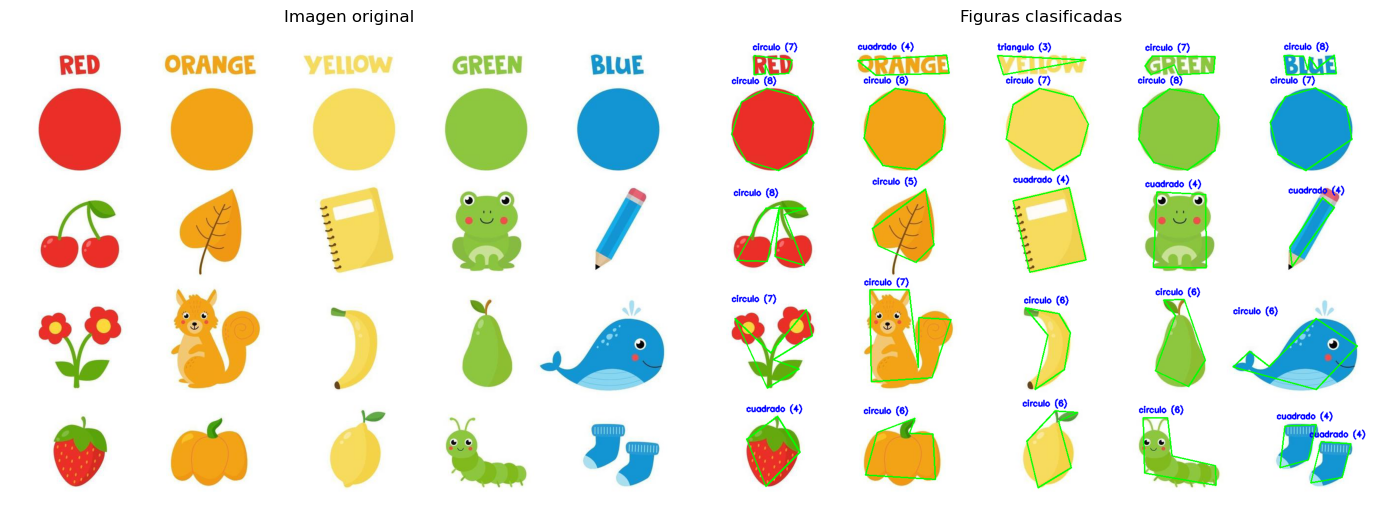

In [12]:
import cv2
import numpy as np
import matplotlib.pyplot as plt


img = cv2.imread('colores.jpg')

def clasificar_figura(vertices, aspect_ratio=None):
    if vertices == 3:
        return "triangulo"
    if vertices == 4:
        return "cuadrado"
    if vertices > 4:
        return "circulo"
    return "desconocida"


hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)

mask = cv2.inRange(hsv, np.array([0, 35, 35]), np.array([179, 255, 255]))
kernel = np.ones((5, 5), np.uint8)
mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel)
mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel)

contornos, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

salida = img.copy()
resultados = []

for indice, contorno in enumerate(contornos, start=1):
    area = cv2.contourArea(contorno)
    if area < 1000:
        continue

    perimetro = cv2.arcLength(contorno, True)
    aproximacion = cv2.approxPolyDP(contorno, 0.04 * perimetro, True)
    vertices = len(aproximacion)

    x, y, ancho, alto = cv2.boundingRect(contorno)
    aspect_ratio = ancho / float(alto)
    figura = clasificar_figura(vertices, aspect_ratio)

    momentos = cv2.moments(contorno)
    hu = cv2.HuMoments(momentos).flatten()

    cv2.drawContours(salida, [aproximacion], -1, (0, 255, 0), 2)
    cv2.putText(
        salida,
        f"{figura} ({vertices})",
        (x, max(20, y - 10)),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.55,
        (255, 0, 0),
        2,
    )

    resultados.append(
        {
            "figura": figura,
            "vertices": vertices,
            "area": area,
            "perimetro": perimetro,
            "aspect_ratio": aspect_ratio,
            "hu_moments": hu,
        }
    )

plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
plt.title("Imagen original")
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.axis("off")

plt.subplot(1, 2, 2)
plt.title("Figuras clasificadas")
plt.imshow(cv2.cvtColor(salida, cv2.COLOR_BGR2RGB))
plt.axis("off")

plt.tight_layout()
plt.show()